# Description

Notebook to create a sin based dataset

In [2]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('Tesis')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
CURRENT_DIR = os.path.join(CURRENT_DIR, 'S-noise-gradient')
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

In [3]:
import numpy as np
import pandas as pd
import pmdarima as pm
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import torch
import random
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
from IPython.display import display, clear_output
from tqdm import tqdm
import math
from scipy import stats

# Locals
from utils import *
from dataset import BioFuelDataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction

In [4]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

In [6]:
def sin_function(x):
    """
    Function that takes in a value x and returns its sin.
    The values are scaled to be between 0 and 1.

    Args:
        x (float): value to be transformed.

    Returns:
        float: value of sin(x) scaled to be between 0 and 1.
    """

    return (1 + np.sin(np.pi * x))/2


def polinomial_function(x):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6


def generate_data(num_points, degree, noise=0.1):
    x = np.random.uniform(-1, 1, num_points)
    y_true = np.polyval(np.random.rand(degree + 1), x)
    y_noisy = y_true #+ noise * np.random.randn(num_points)
    return x, y_noisy


def add_gaussian_noise(df, columns, mean=0, std=0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df


In [7]:
df_train = pd.read_csv(os.path.join(DATA_PATH, 'daily_climate', 'DailyDelhiClimateTrain.csv'), index_col=0)
df_test = pd.read_csv(os.path.join(DATA_PATH, 'daily_climate', 'DailyDelhiClimateTest.csv'), index_col=0)

In [8]:
df_train.index = pd.to_datetime(df_train.index)
df_test.index = pd.to_datetime(df_test.index)

In [9]:
display(df_train.info())
display(df_train.describe().T)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB


None

,count,mean,std,min,25%,50%,75%,max
meantemp,1462.0,25.495521,7.348103,6.000000,18.857143,27.714286,31.305804,38.714286
humidity,1462.0,60.771702,16.769652,13.428571,50.375000,62.625000,72.218750,100.000000
wind_speed,1462.0,6.802209,4.561602,0.000000,3.475000,6.221667,9.238235,42.220000
meanpressure,1462.0,1011.104548,180.231668,-3.041667,1001.580357,1008.563492,1014.944901,7679.333333


In [10]:
# # Crear una figura y los subplots
# fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# # Plotear cada columna en un subplot diferente
# axs[0, 0].plot(df_train['meantemp'])
# axs[0, 0].set_title('meantemp')

# axs[0, 1].plot(df_train['humidity'])
# axs[0, 1].set_title('humidity')

# axs[1, 0].plot(df_train['wind_speed'])
# axs[1, 0].set_title('wind_speed')

# axs[1, 1].plot(df_train['meanpressure'])
# axs[1, 1].set_title('meanpressure')

# # Ajustar el layout para que no haya solapamiento de elementos
# plt.tight_layout()

# # Mostrar la figura
# plt.show()

In [11]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB


In [12]:
# Calc z-scores
z_scores = np.abs(stats.zscore(df_train))
# Filter values with z-score greater than 3
df_train = df_train[(z_scores < 3).all(axis=1)]

# 2nd time to 
# Calc z-scores
z_scores = np.abs(stats.zscore(df_train))
# Filter values with z-score greater than 3
df_train = df_train[(z_scores < 3).all(axis=1)]

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1433 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1433 non-null   float64
 1   humidity      1433 non-null   float64
 2   wind_speed    1433 non-null   float64
 3   meanpressure  1433 non-null   float64
dtypes: float64(4)
memory usage: 56.0 KB


In [14]:
# # Crear una figura y los subplots
# fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# # Plotear cada columna en un subplot diferente
# axs[0, 0].plot(df_train['meantemp'])
# axs[0, 0].set_title('meantemp')

# axs[0, 1].plot(df_train['humidity'])
# axs[0, 1].set_title('humidity')

# axs[1, 0].plot(df_train['wind_speed'])
# axs[1, 0].set_title('wind_speed')

# axs[1, 1].plot(df_train['meanpressure'])
# axs[1, 1].set_title('meanpressure')

# # Ajustar el layout para que no haya solapamiento de elementos
# plt.tight_layout()

# # Mostrar la figura
# plt.show()

In [15]:
full_dates = pd.date_range(df_train.index.min(), df_train.index.max(), freq='D')

# Reindexar la serie para incluir todas las fechas
df_train = df_train.reindex(full_dates)
df_train = df_train.interpolate()

In [16]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Freq: D
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB


In [17]:
scaler = MinMaxScaler()
df_train = pd.DataFrame(scaler.fit_transform(df_train), columns=df_train.columns, index=df_train.index)
df_train.tail()

,meantemp,humidity,wind_speed,meanpressure
2016-12-28,0.342890,0.630865,0.188858,0.764908
2016-12-29,0.282387,0.859736,0.319392,0.807265
2016-12-30,0.247453,0.880638,0.333587,0.838886
2016-12-31,0.276718,0.849835,0.389924,0.781818
2017-01-01,0.122271,1.000000,0.000000,0.778656


In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    df_train[['meantemp']], df_train['meantemp'], 
    test_size=0.2,
    shuffle=False
)

# y_train = pd.DataFrame(y_train.values.reshape(-1, 1), columns=['meantemp'])
# y_val = pd.DataFrame(y_val.values.reshape(-1, 1), columns=['meantemp'])

window_size = int(len(X_train)*0.05)
sliding_window_train = SlidingWindowDataset(X_train, y_train, window_size=window_size, future=1, mode='range')
sliding_window_val = SlidingWindowDataset(X_val, y_val, window_size=window_size, future=1, mode='range')

In [19]:
batch_size = 32
train_dataloader = DataLoader(sliding_window_train, batch_size=batch_size, shuffle=False)
val_dataloader = DataLoader(sliding_window_val, batch_size=batch_size, shuffle=False)

In [20]:
for x, y in train_dataloader:
    print(x[0], y[0])
    break

tensor([[0.1223],
        [0.0428],
        [0.0357],
        [0.0815],
        [0.0000],
        [0.0306],
        [0.0306],
        [0.0873],
        [0.2445],
        [0.1528],
        [0.2969],
        [0.2445],
        [0.3006],
        [0.2089],
        [0.2664],
        [0.2394],
        [0.3210],
        [0.2394],
        [0.1987],
        [0.1616],
        [0.1590],
        [0.1070],
        [0.2445],
        [0.2394],
        [0.1910],
        [0.2038],
        [0.2096],
        [0.2700],
        [0.2484],
        [0.2664],
        [0.3118],
        [0.3057],
        [0.3144],
        [0.3668],
        [0.3493],
        [0.3248],
        [0.3261],
        [0.2934],
        [0.2445],
        [0.2882],
        [0.2828],
        [0.3019],
        [0.2853],
        [0.3144],
        [0.3464],
        [0.4025],
        [0.2576],
        [0.2344],
        [0.2934],
        [0.3013],
        [0.3581],
        [0.4279],
        [0.4432],
        [0.3493],
        [0.3319],
        [0

In [21]:
class GeneralRegression(nn.Module):
    """
    Layers to transform any TSFEDL model into a regression model.

    Args:
        nn (Module): PyTorch module inheritance.
    """
    def __init__(self, in_features, output_size):
        super().__init__()
        self.output_size = output_size
        if not isinstance(self.output_size, int):
            final_output_size = output_size[0] * output_size[1]
        self.fc = nn.Linear(in_features, final_output_size)

    def forward(self, x):
        """
        Performs prediction on the input data in matrix format. Default function
        when calling the model().

        Args:
            x (pd.DataFrame): Input data for inference.

        Returns:
            torch.tensor: Tensor with calculated predictions.
        """
        out = self.fc(x[:, -1, :])
        out = out.view(len(out), self.output_size[0], self.output_size[1])
        return out

In [23]:
# Parámetros del modelo
input_size = X_train.shape[1]
hidden_size = 50
num_layers = 5
output_size = 1

# Definir el criterio y el optimizador
criterion = nn.MSELoss()

model = TSFEDL.OhShuLih(input_size, top_module=GeneralRegression, loss=criterion)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

NameError: name 'TSFEDL' is not defined

In [60]:
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=50,
    epochs=500,
    checkpoints_path=os.path.join(CHECKPOINT_PATH, f'lstm_climate'),
)

In [61]:
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

Training is started!


Epochs loop:  22%|▏| 109/500 [01:04<03:50,  1.70epoch/s, Train loss: 0.0033686199049289163 - Val loss: 0.004

Training stopped as validation loss did not improve for 50 epochs.


In [243]:
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, f'lstm_climate.pth')))

In [62]:
sliding_window_test = SlidingWindowDataset(df_test[['meantemp']], df_test['meantemp'], window_size=window_size, future=1, mode='range')
test_dataloader = DataLoader(sliding_window_test, batch_size=df_test.shape[0], shuffle=False)

In [63]:
y_pred_test = trainer_basic.eval_dataloader(test_dataloader)[0].cpu().detach().numpy()

/mnt/homeGPU/JJavierAR/repsol_env/lib/python3.11/site-packages/torch/nn/modules/rnn.py:879: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /opt/conda/conda-bld/pytorch_1699449183005/work/aten/src/ATen/native/cudnn/RNN.cpp:982.)
  result = _VF.lstm(input, hx, self._flat_weights, self.bias, self.num_layers,


In [25]:
df_to_unscale = df_test.copy()
df_to_unscale['meantemp'].iloc[window_size+1:] = y_pred_test.squeeze()
df_to_unscale = pd.DataFrame(scaler.inverse_transform(df_to_unscale), columns=df_to_unscale.columns, index=df_to_unscale.index)
df_to_unscale['meantemp'].iloc[window_size+1:]

date
2017-03-01    44.410905
2017-03-02    44.411587
2017-03-03    44.410675
2017-03-04    44.410609
2017-03-05    44.410671
2017-03-06    44.410008
2017-03-07    44.410675
2017-03-08    44.410741
2017-03-09    44.410714
2017-03-10    44.410620
2017-03-11    44.410640
2017-03-12    44.410679
2017-03-13    44.410632
2017-03-14    44.410640
2017-03-15    44.410726
2017-03-16    44.410878
2017-03-17    44.411755
2017-03-18    44.410921
2017-03-19    44.410566
2017-03-20    44.410644
2017-03-21    44.410597
2017-03-22    44.410546
2017-03-23    44.410609
2017-03-24    44.409384
2017-03-25    44.408783
2017-03-26    44.408709
2017-03-27    44.408128
2017-03-28    44.406346
2017-03-29    44.403628
2017-03-30    44.403175
2017-03-31    44.402435
2017-04-01    44.402427
2017-04-02    44.401775
2017-04-03    44.401639
2017-04-04    44.400882
2017-04-05    44.400882
2017-04-06    44.400742
2017-04-07    44.400102
2017-04-08    44.400843
2017-04-09    44.400020
2017-04-10    44.401506
2017-04-11 

In [26]:
# df_test['meantemp_pred'] = np.nan
# df_test['meantemp_pred'].iloc[window_size:] = y_pred_test.flatten()
df_test['meantemp'].iloc[window_size:]

date
2017-02-28    23.333333
2017-03-01    24.461538
2017-03-02    23.750000
2017-03-03    20.500000
2017-03-04    19.125000
2017-03-05    19.750000
2017-03-06    20.000000
2017-03-07    22.625000
2017-03-08    21.545455
2017-03-09    20.785714
2017-03-10    19.937500
2017-03-11    18.533333
2017-03-12    17.375000
2017-03-13    17.444444
2017-03-14    18.000000
2017-03-15    19.875000
2017-03-16    24.000000
2017-03-17    20.900000
2017-03-18    24.692308
2017-03-19    24.666667
2017-03-20    23.333333
2017-03-21    25.000000
2017-03-22    27.250000
2017-03-23    28.000000
2017-03-24    28.916667
2017-03-25    26.500000
2017-03-26    29.100000
2017-03-27    29.500000
2017-03-28    29.888889
2017-03-29    31.000000
2017-03-30    29.285714
2017-03-31    30.625000
2017-04-01    31.375000
2017-04-02    29.750000
2017-04-03    30.500000
2017-04-04    30.933333
2017-04-05    29.230769
2017-04-06    31.222222
2017-04-07    27.000000
2017-04-08    25.625000
2017-04-09    27.125000
2017-04-10 

In [270]:
df_to_unscale = df_test.copy()
df_to_unscale['meantemp'].values[window_size+1:] = y_pred_test.squeeze()
df_to_unscale = pd.DataFrame(scaler.inverse_transform(df_to_unscale), columns=df_to_unscale.columns, index=df_to_unscale.index)
y_pred_test = df_to_unscale['meantemp'].values[window_size:]
y_true_test = df_test['meantemp'].values[window_size:]

In [ ]:
y_pred_val = model(torch.tensor(df_val['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [ ]:
y_pred_train = model(torch.tensor(df_noisy['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [ ]:
mae = mean_absolute_error(df_test['y'].values, y_pred_test)
mse = mean_squared_error(df_test['y'].values, y_pred_test)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((df_test['y'].values - y_pred_test) / df_test['y'].values)) * 100
r_squared = r2_score(df_test['y'].values, y_pred_test)
print("MAE: ", mae)
print("MAPE: ", mape)
print("RMSE: ", rmse)
print("MSE: ", mse)
print("R-squared: ", r_squared)

MAE:  0.005742664722035486
MAPE:  inf
RMSE:  0.010359951483379716
MSE:  0.00010732859473798157
R-squared:  0.9973900047760634


/tmp/ipykernel_2186682/1156229740.py:4: RuntimeWarning: divide by zero encountered in divide
  mape = np.mean(np.abs((df_test['y'].values - y_pred_test) / df_test['y'].values)) * 100


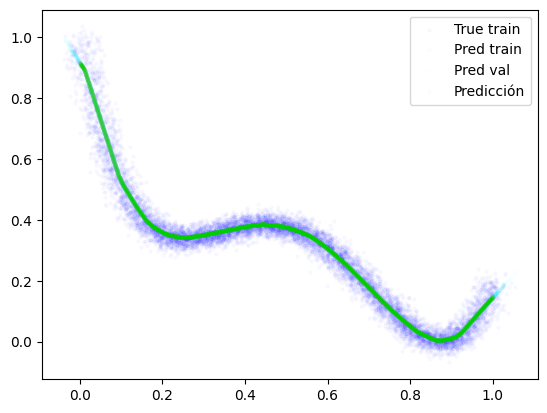

In [ ]:
plt.scatter(df_noisy['X'].values, df_noisy['y'].values, color='b', label='True train', s=5, alpha=0.02)
plt.scatter(df_noisy['X'].values, y_pred_train, color='cyan', label='Pred train', s=5, alpha=0.02)
# plt.scatter(df_val['X'].values, df_val['y'].values, color='r', label='True val', s=5, alpha=0.02)
plt.scatter(df_val['X'].values, y_pred_val, color='pink', label='Pred val', s=5, alpha=0.02)
# plt.scatter(df_test['X'].values, df_test['y'].values, color='g', label='Datos con ruido', s=5, alpha=0.02)
plt.scatter(df_test['X'].values, y_pred_test, color='lime', label='Predicción', s=5, alpha=0.02)
plt.legend()
plt.show()

# Gradients to reduce noise

In [ ]:
df_no_noise = df_noisy.copy()
dlnr = DLNoiseReduction(model=model, criterion=criterion)
dlnr.fit(df_noisy['X'].values.reshape(-1, 1), df_noisy['y'].values.reshape(-1, 1))

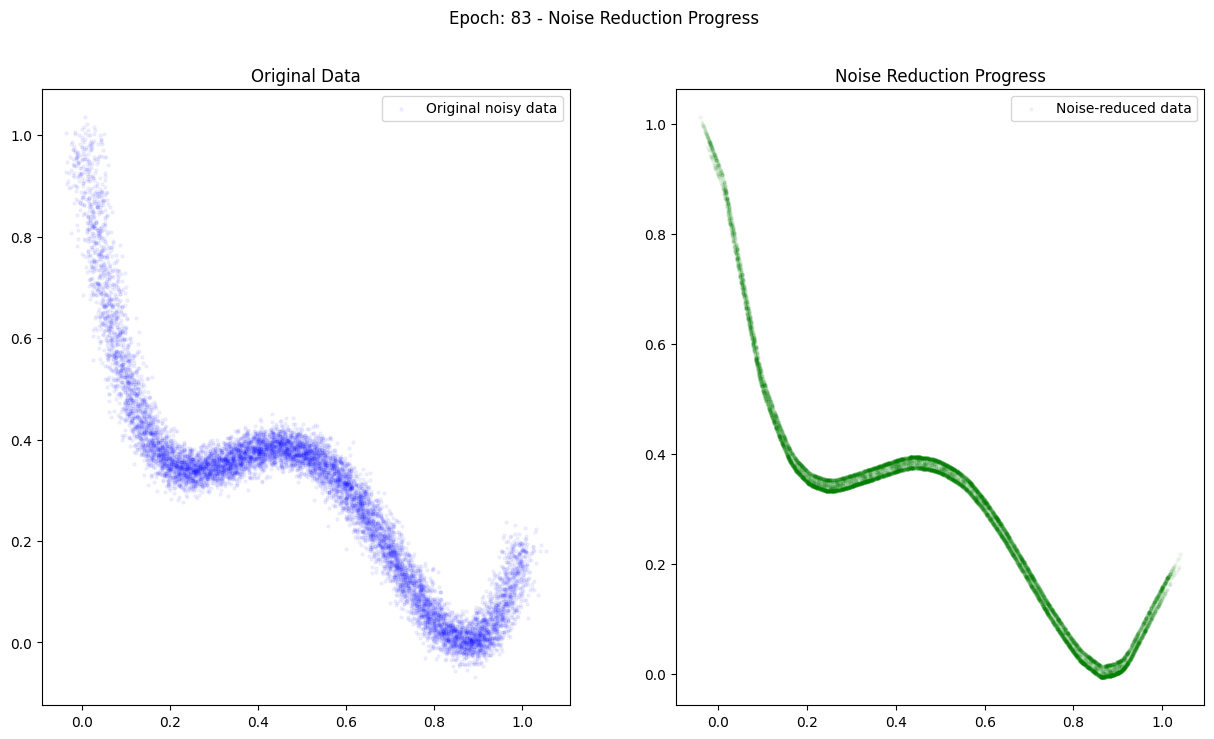

In [ ]:
df_no_noise['X'], df_no_noise['y'] = dlnr.transform(
                                                nrr=0.05,
                                                nr_threshold=0.01,
                                                max_epochs=100,
                                                plot_progress=True
)

In [ ]:
y_polinom_noise = polinomial_function(df_noisy['X'])
y_polinom_denoise = polinomial_function(df_no_noise['X'])
noisy_error = np.sqrt(criterion(torch.tensor(y_polinom_noise), torch.tensor(df_noisy['y'].values)))
denoised_error = np.sqrt(criterion(torch.tensor(y_polinom_denoise), torch.tensor(df_no_noise['y'].values)))
display(noisy_error.item())
display(denoised_error.item())
display(denoised_error.item() < noisy_error.item())

15.942532218080922

15.952932536757904

False

In [ ]:
df_noisy = pd.DataFrame(scaler.inverse_transform(df_noisy))
df_noisy.columns = ['X', 'y']
df_no_noise = pd.DataFrame(scaler.inverse_transform(df_no_noise))
df_no_noise.columns = ['X', 'y']

In [ ]:
y_polinom_noise = polinomial_function(df_noisy['X'])
y_polinom_denoise = polinomial_function(df_no_noise['X'])
noisy_error = np.sqrt(criterion(torch.tensor(y_polinom_noise), torch.tensor(df_noisy['y'].values)))
denoised_error = np.sqrt(criterion(torch.tensor(y_polinom_denoise), torch.tensor(df_no_noise['y'].values)))
display(noisy_error.item())
display(denoised_error.item())
display(denoised_error.item() < noisy_error.item())

24.93430278009703

13.47518147935814

True